In [ ]:
#import pandas as pd
#import plotly.express as px
#TEMPLATE = "plotly_dark"
#COLORS = px.colors.qualitative.Set2

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

TEMPLATE = "plotly_dark"
COLORS = px.colors.qualitative.Set2
SPOTIFY_GREEN = "#1DB954"

In [ ]:
url_top100_songs = "https://raw.githubusercontent.com/Anhtran0208/spotify-aio/refs/heads/main/data/spotify_alltime_top100_songs.csv"
url_wrapped_songs = "https://raw.githubusercontent.com/Anhtran0208/spotify-aio/refs/heads/main/data/spotify_wrapped_2025_top50_songs.csv"
url_wrapped_artists = "https://raw.githubusercontent.com/Anhtran0208/spotify-aio/refs/heads/main/data/spotify_wrapped_2025_top50_artists.csv"

## 1. Data loading

In [ ]:
# load dataset
df_top100_songs = pd.read_csv(url_top100_songs)
df_top100_songs.head(10)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
5,6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
6,7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
7,8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
8,9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100
9,10,Happier,Marshmello & Bastille,3.65,EDM/Pop,100,2018,USA/UK,False,0.62,0.82,0.96,0.02,Spotify All-Time Most Streamed Top 100


In [ ]:
df_wrapped_songs = pd.read_csv(url_wrapped_songs)
df_wrapped_songs.head(10)


,wrapped_2025_rank,song_title,artist,streams_2025_billions,primary_genre,bpm,duration_seconds,release_year,artist_country,explicit,danceability,energy,valence,acousticness,peak_global_chart_position,dataset_part
0,1,Die With A Smile,Lady Gaga & Bruno Mars,1.70,Pop,120,251,2024,USA,False,0.72,0.68,0.55,0.18,1,Spotify Wrapped 2025 Top 50 Global Songs
1,2,APT.,ROSE & Bruno Mars,1.62,K-Pop/Pop,145,173,2024,South Korea,False,0.86,0.79,0.88,0.05,1,Spotify Wrapped 2025 Top 50 Global Songs
2,3,Espresso,Sabrina Carpenter,1.55,Pop,104,175,2024,USA,False,0.80,0.73,0.96,0.06,1,Spotify Wrapped 2025 Top 50 Global Songs
3,4,Please Please Please,Sabrina Carpenter,1.48,Pop,107,186,2024,USA,False,0.70,0.66,0.87,0.10,1,Spotify Wrapped 2025 Top 50 Global Songs
4,5,Taste,Sabrina Carpenter,1.41,Pop,117,177,2024,USA,True,0.78,0.70,0.82,0.08,1,Spotify Wrapped 2025 Top 50 Global Songs
5,6,Birds Of A Feather,Billie Eilish,1.38,Indie Pop,88,210,2024,USA,False,0.75,0.44,0.65,0.38,1,Spotify Wrapped 2025 Top 50 Global Songs
6,7,Not Like Us,Kendrick Lamar,1.35,Hip-Hop,101,274,2024,USA,True,0.82,0.72,0.62,0.04,1,Spotify Wrapped 2025 Top 50 Global Songs
7,8,"Good Luck, Babe!",Chappell Roan,1.29,Pop,131,219,2024,USA,False,0.66,0.78,0.56,0.04,1,Spotify Wrapped 2025 Top 50 Global Songs
8,9,Beautiful Things,Benson Boone,1.24,Pop Rock,97,211,2024,USA,False,0.46,0.68,0.46,0.07,1,Spotify Wrapped 2025 Top 50 Global Songs
9,10,Lose Control,Teddy Swims,1.20,R&B/Soul,90,202,2023,USA,False,0.60,0.55,0.64,0.21,1,Spotify Wrapped 2025 Top 50 Global Songs


In [ ]:
df_wrapped_artists = pd.read_csv(url_wrapped_artists)
df_wrapped_artists.head(10)

,wrapped_2025_rank,artist_name,monthly_listeners_millions_mar2026,primary_genre,country,followers_millions,grammy_wins,debut_year,gender,top_2025_song,dataset_part
0,1,The Weeknd,110.4,R&B/Pop,Canada,112,4,2010,Male,Die With A Smile,Spotify Wrapped 2025 Top 50 Artists
1,2,Taylor Swift,107.5,Pop/Country,USA,110,14,2006,Female,Fortnight,Spotify Wrapped 2025 Top 50 Artists
2,3,Drake,88.6,Hip-Hop,Canada,95,4,2006,Male,Amen,Spotify Wrapped 2025 Top 50 Artists
3,4,Bad Bunny,84.2,Reggaeton,Puerto Rico,89,0,2016,Male,NUEVAYoL,Spotify Wrapped 2025 Top 50 Artists
4,5,Sabrina Carpenter,82.1,Pop,USA,58,0,2015,Female,Espresso,Spotify Wrapped 2025 Top 50 Artists
5,6,Billie Eilish,78.5,Indie Pop,USA,110,9,2015,Female,Birds Of A Feather,Spotify Wrapped 2025 Top 50 Artists
6,7,Ed Sheeran,76.3,Pop/Folk,UK,115,4,2011,Male,Azizam,Spotify Wrapped 2025 Top 50 Artists
7,8,Ariana Grande,72.8,Pop/R&B,USA,94,2,2013,Female,we can't be friends,Spotify Wrapped 2025 Top 50 Artists
8,9,Kendrick Lamar,71.5,Hip-Hop,USA,52,17,2003,Male,Not Like Us,Spotify Wrapped 2025 Top 50 Artists
9,10,Harry Styles,70.2,Pop,UK,80,0,2010,Male,Music For a Sushi Restaurant,Spotify Wrapped 2025 Top 50 Artists


## 2. Explore data

In [ ]:
# shape
print(f"Shape: {df_top100_songs.shape}")

Shape: (100, 14)


In [ ]:
# data types
print(f"Data types: \n{df_top100_songs.dtypes}")

Data types: 
alltime_rank                int64
song_title                 object
artist                     object
total_streams_billions    float64
primary_genre              object
bpm                         int64
release_year                int64
artist_country             object
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part               object
dtype: object


In [ ]:
# null count
print(f"Null count: \n{df_top100_songs.isnull().sum()}")
# NaN count
print(f"\nNaN count: \n{df_top100_songs.isna().sum()}")

Null count: 
alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

NaN count: 
alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64


In [ ]:
for col in df_top100_songs.columns:
  print(f"Columns: {col} \n")
  print(df_top100_songs[col].value_counts())

Columns: alltime_rank 

alltime_rank
1      1
2      1
3      1
4      1
5      1
      ..
96     1
97     1
98     1
99     1
100    1
Name: count, Length: 100, dtype: int64
Columns: song_title 

song_title
Blinding Lights            1
Shape of You               1
Someone You Loved          1
Sunflower                  1
One Dance                  1
                          ..
Electricity                1
Blinding Lights (Remix)    1
Falling For You            1
Laugh Now Cry Later        1
Shake It Off               1
Name: count, Length: 100, dtype: int64
Columns: artist 

artist
Ed Sheeran              5
Harry Styles            5
Imagine Dragons         3
The Weeknd              3
Taylor Swift            3
                       ..
Cyril & Violet Skies    1
Silk City & Dua Lipa    1
The Weeknd & Rosalía    1
Peachy feat. mxmtoon    1
Drake ft. Lil Durk      1
Name: count, Length: 80, dtype: int64
Columns: total_streams_billions 

total_streams_billions
1.60    4
1.62    2
1.44    

## 3. Data cleaning

In [ ]:
# Drop dataset_part column
df_top100_songs_copy = df_top100_songs.copy()
df_top100_songs_copy = df_top100_songs_copy.drop(columns=['dataset_part'])

In [ ]:
# strip text column
text_cols = ["song_title", "artist", "primary_genre", "artist_country"]
for col in text_cols:
    df_top100_songs_copy[col] = df_top100_songs_copy[col].astype(str).str.strip()

In [ ]:
# handle artist_country column
df_top100_songs_copy['artist_country'] = df_top100_songs_copy['artist_country'].replace({
    "NZ/USA": "New Zealand/USA"
})

In [ ]:
# sort value for genre
def sort_genre(genre):
  genre_arr = [g.strip() for g in genre.split('/')]
  if len(genre_arr) > 1:
    sorted_genre = sorted(genre_arr)
    return "/".join(sorted_genre)
  return genre
df_top100_songs_copy['primary_genre'] = df_top100_songs_copy['primary_genre'].apply(sort_genre)

In [ ]:
print(df_top100_songs_copy.head())

   alltime_rank         song_title                  artist  \
0             1    Blinding Lights              The Weeknd   
1             2       Shape of You              Ed Sheeran   
2             3  Someone You Loved           Lewis Capaldi   
3             4          Sunflower  Post Malone & Swae Lee   
4             5          One Dance                   Drake   

   total_streams_billions  primary_genre  bpm  release_year artist_country  \
0                    5.26      Synth-Pop  171          2019         Canada   
1                    4.90  Dancehall/Pop   96          2017             UK   
2                    4.05            Pop   77          2018             UK   
3                    3.98    Hip-Hop/Pop   93          2018            USA   
4                    3.92  Afrobeats/Pop  100          2016         Canada   

   explicit  danceability  energy  valence  acousticness  
0     False          0.51    0.80     0.33          0.00  
1     False          0.83    0.65     0.

In [ ]:
# Clean wrapped songs (same steps as Section 3)
df_wrapped_songs = df_wrapped_songs.drop(columns=["dataset_part"], errors="ignore")
for col in ["song_title", "artist", "primary_genre", "artist_country"]:
    df_wrapped_songs[col] = df_wrapped_songs[col].astype(str).str.strip()

In [ ]:
# Clean wrapped artists
df_wrapped_artists = df_wrapped_artists.drop(columns=["dataset_part"], errors="ignore")
for col in ["artist_name", "primary_genre", "country", "top_2025_song"]:
    df_wrapped_artists[col] = df_wrapped_artists[col].astype(str).str.strip()

In [ ]:
print(f"Wrapped 2025 Songs: {df_wrapped_songs.shape}")
print(f"Wrapped 2025 Artists: {df_wrapped_artists.shape}")

Wrapped 2025 Songs: (50, 15)
Wrapped 2025 Artists: (50, 10)


## 4. EDA + Visualization

In [ ]:
# Streams Distribution
median_streams = df_top100_songs_copy['total_streams_billions'].median()
fig = px.histogram(df_top100_songs_copy, x='total_streams_billions', nbins=20,
                   title='Distribution of Total Streams (Billions)',
                   template=TEMPLATE, color_discrete_sequence=['#1DB954'])
fig.add_vline(x=median_streams, line_dash="dash", line_color="red",
              annotation_text=f"Median: {median_streams:.2f}B")
fig.show()

In [ ]:
# Top 15 Artists
artist_counts = df_top100_songs_copy['artist'].value_counts().head(15).reset_index()
artist_counts.columns = ['artist', 'count']
fig = px.bar(artist_counts, x='count', y='artist', orientation='h',
             title='Top 15 Artists by Song Count', template=TEMPLATE,
             color='count', color_continuous_scale='Greens')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [ ]:
# Genre + Country + Year
# Genre grouping
top_genres = df_top100_songs_copy['primary_genre'].value_counts().head(8).index.tolist()
df_top100_songs_copy['genre_group'] = df_top100_songs_copy['primary_genre'].apply(lambda x: x if x in top_genres else 'Other')

fig_genre = px.pie(df_top100_songs_copy['genre_group'].value_counts().reset_index(),
                   values='count', names='genre_group',
                   title='Genre Distribution', template=TEMPLATE,
                   color_discrete_sequence=COLORS, hole=0.4)
fig_genre.show()
df_top100_songs_copy['artist_country_primary'] = df_top100_songs_copy['artist_country'].apply(lambda x: x.split('/')[0].strip())
fig_country = px.bar(df_top100_songs_copy['artist_country_primary'].value_counts().head(10).reset_index(),
                     x='artist_country_primary', y='count',
                     title='Top 10 Artist Countries', template=TEMPLATE,
                     color='count', color_continuous_scale='Tealgrn')
fig_country.show()

year_counts = df_top100_songs_copy['release_year'].value_counts().sort_index().reset_index()
fig_year = px.bar(year_counts, x='release_year', y='count',
                  title='Release Year Distribution', template=TEMPLATE,
                  color='count', color_continuous_scale='Viridis')
fig_year.show()

In [ ]:
# Audio Features
audio_cols = ['danceability', 'energy', 'valence', 'acousticness']
df_melt = df_top100_songs_copy[audio_cols].melt(var_name='Feature', value_name='Value')
fig = px.box(df_melt, x='Feature', y='Value', color='Feature',
             title='Audio Features Distribution', template=TEMPLATE,
             color_discrete_sequence=COLORS)
fig.show()

In [ ]:
df_top100_songs_copy['song_age'] = 2025 - df_top100_songs_copy['release_year']

fig1 = px.scatter(df_top100_songs_copy, x='bpm', y='total_streams_billions', color='genre_group',
                  size='song_age', hover_data=['song_title', 'artist'],
                  title='Streams vs BPM', template=TEMPLATE, color_discrete_sequence=COLORS)
fig1.show()

median_streams = df_top100_songs_copy['total_streams_billions'].median()
df_top100_songs_copy['popularity_class'] = (df_top100_songs_copy['total_streams_billions'] >= median_streams).astype(int)
df_top100_songs_copy['popularity_label'] = df_top100_songs_copy['popularity_class'].map({0: 'Low', 1: 'High'})

fig2 = px.scatter(df_top100_songs_copy, x='danceability', y='total_streams_billions',
                  color='popularity_label', size='energy',
                  hover_data=['song_title', 'artist'],
                  title='Streams vs Danceability', template=TEMPLATE,
                  color_discrete_sequence=['#FF6B6B', '#1DB954'])
fig2.show()

## 5. Comparative analysis

### 5.1  CROSSOVER HITS — Songs in Both Datasets

In [ ]:
# Find overlapping songs by title (case-insensitive)
df_wrapped_songs["title_key"] = df_wrapped_songs["song_title"].str.lower()
df_top100_songs_copy["title_key"] = df_top100_songs_copy["song_title"].str.lower()

df_overlap = df_wrapped_songs.merge(
    df_top100_songs_copy[["title_key", "alltime_rank", "total_streams_billions"]],
    on="title_key",
    how="inner"
)

print(f"\n{'='*50}")
print(f"Songs appearing in BOTH datasets: {len(df_overlap)}")
print(f"{'='*50}")
print(df_overlap[["song_title", "artist", "wrapped_2025_rank", "alltime_rank",
                   "streams_2025_billions", "total_streams_billions"]].to_string(index=False))


Songs appearing in BOTH datasets: 15
          song_title                  artist  wrapped_2025_rank  alltime_rank  streams_2025_billions  total_streams_billions
    Die With A Smile  Lady Gaga & Bruno Mars                  1            50                   1.70                    1.84
                APT.       ROSE & Bruno Mars                  2            77                   1.62                    1.66
            Espresso       Sabrina Carpenter                  3            41                   1.55                    1.76
         Not Like Us          Kendrick Lamar                  7            44                   1.35                    1.50
    Beautiful Things            Benson Boone                  9            74                   1.24                    1.40
        Lose Control             Teddy Swims                 10            82                   1.20                    1.65
           Too Sweet                  Hozier                 11            83          

In [ ]:
# ── Scatter: Wrapped rank vs All-Time rank ──
fig = px.scatter(
    df_overlap,
    x="wrapped_2025_rank",
    y="alltime_rank",
    text="song_title",
    size="streams_2025_billions",
    color="streams_2025_billions",
    color_continuous_scale=["#a855f7", SPOTIFY_GREEN],
    title="Crossover Hits: Wrapped 2025 Rank vs All-Time Rank",
    labels={
        "wrapped_2025_rank": "Wrapped 2025 Rank (← higher)",
        "alltime_rank": "All-Time Rank (← higher)",
        "streams_2025_billions": "2025 Streams (B)"
    },
    template=TEMPLATE,
    size_max=20
)
fig.update_traces(textposition="top center", textfont_size=9)
fig.update_xaxes(autorange="reversed")
fig.update_yaxes(autorange="reversed")
fig.update_layout(height=550)
fig.show()

In [ ]:
# ── Bar: 2025 Streams vs All-Time Total for overlap songs ──
df_overlap_sorted = df_overlap.sort_values("wrapped_2025_rank").head(10)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_overlap_sorted["song_title"],
    x=df_overlap_sorted["streams_2025_billions"],
    name="2025 Streams",
    orientation="h",
    marker_color=SPOTIFY_GREEN
))
fig.add_trace(go.Bar(
    y=df_overlap_sorted["song_title"],
    x=df_overlap_sorted["total_streams_billions"],
    name="All-Time Total",
    orientation="h",
    marker_color="#a855f7"
))
fig.update_layout(
    title="Stream Velocity: 2025 Contribution vs All-Time Total",
    barmode="group",
    template=TEMPLATE,
    yaxis=dict(categoryorder="array",
               categoryarray=df_overlap_sorted.sort_values("wrapped_2025_rank", ascending=False)["song_title"].tolist()),
    xaxis_title="Streams (Billions)",
    height=450
)
fig.show()

In [ ]:
# Compute 2025's share of all-time total
df_overlap["pct_2025"] = (df_overlap["streams_2025_billions"] / df_overlap["total_streams_billions"] * 100).round(1)
print("\n── 2025 Stream Share of All-Time Total ──")
print(df_overlap[["song_title", "pct_2025"]].sort_values("pct_2025", ascending=False).to_string(index=False))


── 2025 Stream Share of All-Time Total ──
          song_title  pct_2025
                APT.      97.6
    Die With A Smile      92.4
         Not Like Us      90.0
    Beautiful Things      88.6
            Espresso      88.1
        Lose Control      72.7
           Too Sweet      72.4
       Levii's Jeans      54.8
    End Of Beginning      43.7
        Stumblin' In      41.8
            good 4 u      41.2
Running Up That Hill      40.8
        Shake It Off      37.5
        Cruel Summer      35.3
             Flowers      31.0


### 5.2  GENRE SHIFT — Wrapped 2025 vs All-Time

In [ ]:
# Simplify genres into broader buckets for comparison
def simplify_genre(g):
    g = g.lower()
    if "country" in g: return "Country"
    if "k-pop" in g: return "K-Pop"
    if "reggaeton" in g or "latin" in g: return "Latin/Reggaeton"
    if "hip-hop" in g or "rap" in g: return "Hip-Hop/Rap"
    if "r&b" in g or "soul" in g: return "R&B/Soul"
    if "afrobeat" in g: return "Afrobeats"
    if "indie" in g: return "Indie"
    if "alt" in g or "rock" in g or "punk" in g or "grunge" in g: return "Rock/Alt"
    if "edm" in g or "disco" in g or "electro" in g or "dance" in g: return "Electronic/Dance"
    if "synth" in g: return "Synth-Pop"
    if "folk" in g: return "Folk"
    return "Pop"

df_wrapped_songs["genre_group"] = df_wrapped_songs["primary_genre"].apply(simplify_genre)
df_top100_songs_copy["genre_group"] = df_top100_songs_copy["primary_genre"].apply(simplify_genre)

genre_w = df_wrapped_songs["genre_group"].value_counts().reset_index()
genre_w.columns = ["genre", "count"]
genre_w["dataset"] = "Wrapped 2025"
genre_w["pct"] = (genre_w["count"] / 50 * 100).round(1)

genre_at = df_top100_songs_copy["genre_group"].value_counts().reset_index()
genre_at.columns = ["genre", "count"]
genre_at["dataset"] = "All-Time Top 100"
genre_at["pct"] = (genre_at["count"] / 100 * 100).round(1)

genre_combined = pd.concat([genre_w, genre_at])

fig = px.bar(
    genre_combined,
    x="genre", y="pct", color="dataset",
    barmode="group",
    title="Genre Distribution: Wrapped 2025 vs All-Time Top 100 (%)",
    labels={"pct": "Percentage (%)", "genre": "Genre"},
    color_discrete_map={"Wrapped 2025": SPOTIFY_GREEN, "All-Time Top 100": "#a855f7"},
    template=TEMPLATE
)
fig.update_layout(
    xaxis=dict(categoryorder="total descending"),
    height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

### 5.3  AUDIO DNA — Feature Comparison (Radar Chart)

In [ ]:
audio_cols = ["danceability", "energy", "valence", "acousticness"]

means_w = df_wrapped_songs[audio_cols].mean()
means_at = df_top100_songs_copy[audio_cols].mean()

fig = go.Figure()
fig.add_trace(go.Scatterpolar(
    r=means_w.tolist() + [means_w.tolist()[0]],
    theta=audio_cols + [audio_cols[0]],
    fill="toself",
    name="Wrapped 2025",
    line_color=SPOTIFY_GREEN,
    fillcolor="rgba(29,185,84,0.15)"
))
fig.add_trace(go.Scatterpolar(
    r=means_at.tolist() + [means_at.tolist()[0]],
    theta=audio_cols + [audio_cols[0]],
    fill="toself",
    name="All-Time Top 100",
    line_color="#a855f7",
    fillcolor="rgba(168,85,247,0.15)"
))
fig.update_layout(
    title="Audio DNA: Wrapped 2025 vs All-Time Top 100",
    template=TEMPLATE,
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 0.8]),
        bgcolor="rgba(0,0,0,0)"
    ),
    height=500
)
fig.show()

# ── Box plot comparison for each audio feature ──
df_w_melt = df_wrapped_songs[audio_cols].melt(var_name="Feature", value_name="Value")
df_w_melt["Dataset"] = "Wrapped 2025"
df_at_melt = df_top100_songs_copy[audio_cols].melt(var_name="Feature", value_name="Value")
df_at_melt["Dataset"] = "All-Time Top 100"
df_audio_compare = pd.concat([df_w_melt, df_at_melt])

fig = px.box(
    df_audio_compare, x="Feature", y="Value", color="Dataset",
    title="Audio Feature Distributions: Side-by-Side Comparison",
    template=TEMPLATE,
    color_discrete_map={"Wrapped 2025": SPOTIFY_GREEN, "All-Time Top 100": "#a855f7"}
)
fig.update_layout(height=450)
fig.show()

# Print mean differences
print("\n── Audio Feature Means ──")
diff_df = pd.DataFrame({
    "Feature": audio_cols,
    "Wrapped 2025": means_w.values.round(3),
    "All-Time": means_at.values.round(3),
    "Diff (W-AT)": (means_w.values - means_at.values).round(3)
})
print(diff_df.to_string(index=False))



── Audio Feature Means ──
     Feature  Wrapped 2025  All-Time  Diff (W-AT)
danceability         0.682     0.614        0.068
      energy         0.647     0.636        0.011
     valence         0.666     0.551        0.115
acousticness         0.152     0.153       -0.001


### 5.4  GEOGRAPHY — Artist Origins

In [ ]:
def primary_country(c):
    """Extract first country from multi-country strings like 'USA/UK'"""
    return c.split("/")[0].strip()

country_w = df_wrapped_songs["artist_country"].apply(primary_country).value_counts().reset_index()
country_w.columns = ["country", "count"]
country_w["dataset"] = "Wrapped 2025"

country_at = df_top100_songs_copy["artist_country"].apply(primary_country).value_counts().reset_index()
country_at.columns = ["country", "count"]
country_at["dataset"] = "All-Time Top 100"

country_combined = pd.concat([country_w, country_at])

fig = px.bar(
    country_combined,
    x="country", y="count", color="dataset",
    barmode="group",
    title="Artist Origin: Wrapped 2025 vs All-Time Top 100",
    labels={"count": "Number of Songs"},
    color_discrete_map={"Wrapped 2025": SPOTIFY_GREEN, "All-Time Top 100": "#a855f7"},
    template=TEMPLATE
)
fig.update_layout(
    xaxis=dict(categoryorder="total descending"),
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

# Non-US/UK share comparison
non_western_w = df_wrapped_songs["artist_country"].apply(primary_country)
non_western_w = (non_western_w[~non_western_w.isin(["USA", "UK", "Canada", "Australia"])].count() / 50 * 100).round(1)

non_western_at = df_top100_songs_copy["artist_country"].apply(primary_country)
non_western_at = (non_western_at[~non_western_at.isin(["USA", "UK", "Canada", "Australia"])].count() / 100 * 100).round(1)

print(f"\n── Global South / Non-Anglophone Share ──")
print(f"  Wrapped 2025: {non_western_w}%")
print(f"  All-Time:     {non_western_at}%")



── Global South / Non-Anglophone Share ──
  Wrapped 2025: 18.0%
  All-Time:     13.0%


### 5.5  ARTIST POWER — Top 50 Artists Deep Dive

In [ ]:
# ── Grammy Wins vs Streaming Rank ──
fig = px.scatter(
    df_wrapped_artists,
    x="wrapped_2025_rank",
    y="grammy_wins",
    size="monthly_listeners_millions_mar2026",
    color="gender",
    text="artist_name",
    title="Grammy Wins vs Wrapped 2025 Rank (bubble = monthly listeners)",
    labels={
        "wrapped_2025_rank": "Wrapped 2025 Rank (← higher)",
        "grammy_wins": "Grammy Wins",
        "monthly_listeners_millions_mar2026": "Monthly Listeners (M)"
    },
    color_discrete_map={"Male": "#3b82f6", "Female": "#e84393", "Group": "#a855f7"},
    template=TEMPLATE,
    size_max=30
)
fig.update_traces(textposition="top center", textfont_size=8)
fig.update_xaxes(autorange="reversed")
fig.update_layout(height=550)
fig.show()

zero_grammys = (df_wrapped_artists["grammy_wins"] == 0).sum()
print(f"\n── Grammy Stats ──")
print(f"  Artists with 0 Grammys: {zero_grammys}/50 ({zero_grammys/50*100:.0f}%)")
print(f"  Top Grammy holders in Wrapped 2025:")
print(df_wrapped_artists.nlargest(5, "grammy_wins")[["artist_name", "grammy_wins"]].to_string(index=False))


── Grammy Stats ──
  Artists with 0 Grammys: 26/50 (52%)
  Top Grammy holders in Wrapped 2025:
   artist_name  grammy_wins
       Beyoncé           32
Kendrick Lamar           17
    Bruno Mars           15
        Eminem           15
  Taylor Swift           14


In [ ]:
# ── Gender Representation ──
gender_counts = df_wrapped_artists["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

fig = px.pie(
    gender_counts,
    values="count", names="gender",
    title="Gender Representation in Wrapped 2025 Top 50 Artists",
    color="gender",
    color_discrete_map={"Male": "#3b82f6", "Female": "#e84393", "Group": "#a855f7"},
    template=TEMPLATE,
    hole=0.45
)
fig.update_layout(height=400)
fig.show()

In [ ]:
# ── New vs Veteran Artists ──
df_wrapped_artists["era"] = pd.cut(
    df_wrapped_artists["debut_year"],
    bins=[0, 2009, 2014, 2019, 2030],
    labels=["Pre-2010 Legacy", "2010-14 Established", "2015-19 Mid-Gen", "2020+ Newcomer"]
)
era_counts = df_wrapped_artists["era"].value_counts().reset_index()
era_counts.columns = ["era", "count"]

fig = px.bar(
    era_counts.sort_values("era"),
    x="era", y="count",
    title="Artist Debut Era in Wrapped 2025 Top 50",
    color="era",
    color_discrete_sequence=[COLORS[0], COLORS[1], COLORS[2], COLORS[3]],
    template=TEMPLATE
)
fig.update_layout(height=400, showlegend=False)
fig.show()

In [ ]:
# ── Artists with Most Songs in Wrapped 2025 Top 50 ──
from collections import Counter
artist_song_counts = Counter()
for _, row in df_wrapped_songs.iterrows():
    artists = row["artist"].replace(" ft. ", " & ").split(" & ")
    for a in artists:
        artist_song_counts[a.strip()] += 1

top_artists_df = pd.DataFrame(
    artist_song_counts.most_common(12),
    columns=["artist", "song_count"]
)
fig = px.bar(
    top_artists_df,
    x="song_count", y="artist",
    orientation="h",
    title="Artists with Most Songs in Wrapped 2025 Top 50",
    color="song_count",
    color_continuous_scale=[[0, "#a855f7"], [1, SPOTIFY_GREEN]],
    template=TEMPLATE
)
fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    height=450
)
fig.show()

### 5.6  BPM & DURATION COMPARISON

In [ ]:
# ── BPM distribution overlay ──
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df_wrapped_songs["bpm"],
    name="Wrapped 2025",
    marker_color=SPOTIFY_GREEN,
    opacity=0.7,
    nbinsx=20
))
fig.add_trace(go.Histogram(
    x=df_top100_songs_copy["bpm"],
    name="All-Time Top 100",
    marker_color="#a855f7",
    opacity=0.7,
    nbinsx=20
))
fig.update_layout(
    title="BPM Distribution: Wrapped 2025 vs All-Time Top 100",
    barmode="overlay",
    xaxis_title="BPM",
    yaxis_title="Count",
    template=TEMPLATE,
    height=400
)
fig.show()

print(f"\n── BPM Stats ──")
print(f"  Wrapped 2025:  mean={df_wrapped_songs['bpm'].mean():.1f}, median={df_wrapped_songs['bpm'].median()}")
print(f"  All-Time:      mean={df_top100_songs_copy['bpm'].mean():.1f}, median={df_top100_songs_copy['bpm'].median()}")


── BPM Stats ──
  Wrapped 2025:  mean=109.8, median=104.0
  All-Time:      mean=115.8, median=107.0


### 5.7  DANCEABILITY vs VALENCE — Mood Scatter

In [ ]:
df_wrapped_songs["source"] = "Wrapped 2025"
df_top100_songs_copy["source"] = "All-Time Top 100"

# Combine for scatter (only shared columns)
shared_cols = ["song_title", "artist", "danceability", "valence", "energy", "source"]
df_scatter = pd.concat([
    df_wrapped_songs[shared_cols],
    df_top100_songs_copy[shared_cols]
])

fig = px.scatter(
    df_scatter,
    x="danceability", y="valence",
    color="source",
    size="energy",
    hover_data=["song_title", "artist"],
    title="Mood Map: Danceability vs Valence (bubble = energy)",
    color_discrete_map={"Wrapped 2025": SPOTIFY_GREEN, "All-Time Top 100": "#a855f7"},
    template=TEMPLATE,
    opacity=0.7,
    size_max=14
)
fig.update_layout(height=550)
fig.show()

### 5.8  SUMMARY STATISTICS TABLE

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Songs", "Avg Danceability", "Avg Energy", "Avg Valence",
        "Avg Acousticness", "Avg BPM", "Explicit %",
        "USA Artist %", "Median Streams (B)"
    ],
    "Wrapped 2025": [
        50,
        round(df_wrapped_songs["danceability"].mean(), 3),
        round(df_wrapped_songs["energy"].mean(), 3),
        round(df_wrapped_songs["valence"].mean(), 3),
        round(df_wrapped_songs["acousticness"].mean(), 3),
        round(df_wrapped_songs["bpm"].mean(), 1),
        f"{(df_wrapped_songs['explicit'].sum() / 50 * 100):.0f}%",
        f"{(df_wrapped_songs['artist_country'].apply(primary_country).eq('USA').sum() / 50 * 100):.0f}%",
        round(df_wrapped_songs["streams_2025_billions"].median(), 2)
    ],
    "All-Time Top 100": [
        100,
        round(df_top100_songs_copy["danceability"].mean(), 3),
        round(df_top100_songs_copy["energy"].mean(), 3),
        round(df_top100_songs_copy["valence"].mean(), 3),
        round(df_top100_songs_copy["acousticness"].mean(), 3),
        round(df_top100_songs_copy["bpm"].mean(), 1),
        f"{(df_top100_songs_copy['explicit'].sum() / 100 * 100):.0f}%",
        f"{(df_top100_songs_copy['artist_country'].apply(primary_country).eq('USA').sum() / 100 * 100):.0f}%",
        round(df_top100_songs_copy["total_streams_billions"].median(), 2)
    ]
})

print("\n" + "═"*60)
print("  COMPARATIVE SUMMARY")
print("═"*60)
print(summary.to_string(index=False))


════════════════════════════════════════════════════════════
  COMPARATIVE SUMMARY
════════════════════════════════════════════════════════════
            Metric Wrapped 2025 All-Time Top 100
       Total Songs           50              100
  Avg Danceability        0.682            0.614
        Avg Energy        0.647            0.636
       Avg Valence        0.666            0.551
  Avg Acousticness        0.152            0.153
           Avg BPM        109.8            115.8
        Explicit %          14%              13%
      USA Artist %          74%              54%
Median Streams (B)         0.84             2.44


In [ ]:
fig = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Metric</b>", "<b>Wrapped 2025</b>", "<b>All-Time Top 100</b>"],
        fill_color="#1a1a2e",
        font=dict(color="white", size=13),
        align="left",
        height=35
    ),
    cells=dict(
        values=[summary[col] for col in summary.columns],
        fill_color=[["#0f0f1a"]*len(summary), ["#162016"]*len(summary), ["#1a1430"]*len(summary)],
        font=dict(color="white", size=12),
        align="left",
        height=30
    )
)])
fig.update_layout(
    title="Comparative Summary: Wrapped 2025 vs All-Time Top 100",
    template=TEMPLATE,
    height=400
)
fig.show()

## 6. Model

In [ ]:
#Unsupervised learning to cluster types of songs that exist in top 100
df_top100_songs_copy

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,genre_group,artist_country_primary,title_key,source
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Synth-Pop,Canada,blinding lights,All-Time Top 100
1,2,Shape of You,Ed Sheeran,4.90,Dancehall/Pop,96,2017,UK,False,0.83,0.65,0.93,0.08,Electronic/Dance,UK,shape of you,All-Time Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Pop,UK,someone you loved,All-Time Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Hip-Hop/Rap,USA,sunflower,All-Time Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Afrobeats,Canada,one dance,All-Time Top 100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Electricity,Silk City & Dua Lipa,1.92,EDM/Pop,143,2018,UK,False,0.76,0.88,0.72,0.00,Electronic/Dance,UK,electricity,All-Time Top 100
96,97,Blinding Lights (Remix),The Weeknd & Rosalía,1.44,Synth-Pop,171,2020,Canada/Spain,False,0.54,0.80,0.36,0.01,Synth-Pop,Canada,blinding lights (remix),All-Time Top 100
97,98,Falling For You,Peachy feat. mxmtoon,1.56,Indie Pop,150,2018,USA,False,0.64,0.42,0.72,0.38,Indie,USA,falling for you,All-Time Top 100
98,99,Laugh Now Cry Later,Drake ft. Lil Durk,3.05,Hip-Hop,142,2020,Canada,True,0.82,0.62,0.55,0.02,Hip-Hop/Rap,Canada,laugh now cry later,All-Time Top 100


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

features = [
    "danceability", "energy", "valence",
    "acousticness", "bpm"
]

X = df_top100_songs_copy[["danceability", "energy", "valence", "acousticness", "bpm"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

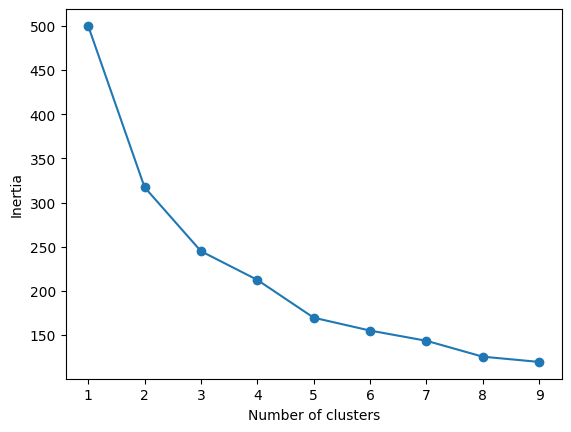

In [ ]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

Choose K = 3

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)  # cluster assignments for each song
centroids = kmeans.cluster_centers_     # cluster centers
df_top100_songs_copy['cluster'] = labels

In [ ]:
import plotly.express as px
import pandas as pd

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Convert PCA result to DataFrame
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_plot['cluster'] = df_top100_songs_copy['cluster']

# Create interactive 3D scatter plot
fig = px.scatter_3d(
    df_plot,
    x='PC1', y='PC2', z='PC3',
    color='cluster',
    title=f'3D PCA of Spotify Songs Clusters (K={K})',
    width=800, height=600
)

fig.show()

In [ ]:
df_top100_songs_copy['cluster'].value_counts()

,count
cluster,
2,44
1,30
0,26


In [ ]:
cluster_summary = df_top100_songs_copy.groupby('cluster')[features].mean()
print(cluster_summary)

         danceability    energy   valence  acousticness         bpm
cluster                                                            
0            0.508077  0.434615  0.355000      0.344615   85.307692
1            0.546333  0.746000  0.454667      0.062333  145.733333
2            0.721591  0.680227  0.731591      0.102500  113.363636


Cluster 0:

Try K = 2 to see what we might have

In [ ]:
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features
features = ["danceability", "energy", "valence", "acousticness", "bpm"]
X = df_top100_songs_copy[features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans with K=2
K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_top100_songs_copy['cluster'] = labels

# PCA to 3 components for 3D visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Put PCA results into dataframe
df_pca = df_top100_songs_copy.copy()
df_pca['PC1'] = X_pca[:,0]
df_pca['PC2'] = X_pca[:,1]
df_pca['PC3'] = X_pca[:,2]

# 3D interactive scatter plot
fig = px.scatter_3d(
    df_pca,
    x='PC1', y='PC2', z='PC3',
    color='cluster',
    hover_data=['artist', 'song_title'],  # show artist/song on hover
    color_continuous_scale='Viridis',
    title=f"3D PCA of Spotify Songs Clusters (K={K})"
)

fig.update_traces(marker=dict(size=5))  # marker size
fig.show()

In [ ]:
df_top100_songs_copy['cluster'].value_counts()

,count
cluster,
1,71
0,29


In [ ]:
cluster_summary = df_top100_songs_copy.groupby('cluster')[features].mean()
print(cluster_summary)

         danceability    energy   valence  acousticness         bpm
cluster                                                            
0            0.501034  0.461379  0.353103      0.318966   85.655172
1            0.659437  0.707465  0.631268      0.085775  128.084507
